In [20]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [21]:
# Load dataset
df = pd.read_csv("Training Set_16.csv",index_col=0)
df

,Exp_syn,Exp_anti,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),BA (C28-Pd-C12),...,E_dxz_Pd,E_dyz_Pd,E_dx2y2_Pd,E_dz2_Pd,E_Pd(LP)-C28(LP*),E_Pd(LP)-C12(LP*),E_C28(LP)-Pd(LP*),E_C12(LP)-Pd(LP*),Occ._Pd(LP),E_Pd(LP)
Ligand Name,,,,,,,,,,,,,,,,,,,,,
5-IMes,1.00,2.00,-0.484674,-1804.2453,-1804.7901,0.544791,-1806.2855,2.05604,1.98859,175.22297,...,-0.25111,-0.23408,-0.24280,-0.25121,31.60,61.84,221.94,251.94,1.73952,-0.23268
5-IMes(Me),1.00,1.80,-0.411002,-1882.8182,-1883.4157,0.597507,-1884.9254,2.05896,1.98482,175.14773,...,-0.24786,-0.23158,-0.24162,-0.24870,30.16,63.78,219.11,247.82,1.73538,-0.22952
5-IPr,1.80,1.00,0.411002,-2039.8947,-2040.6098,0.715108,-2042.1522,2.06852,1.98918,170.23798,...,-0.25299,-0.23952,-0.25146,-0.25613,29.49,62.57,198.12,226.10,1.73784,-0.23608
"5-IPr*(Me, Ph)",4.00,1.00,0.969348,-2884.9649,-2885.9336,0.968654,-2887.6474,2.07858,1.97721,165.88900,...,-0.26154,-0.25844,-0.26562,-0.25147,24.49,66.27,171.17,206.26,1.73388,-0.24368
5-IPr**,6.14,1.00,1.268993,-4908.3608,-4910.3959,2.035083,-4912.5098,2.07065,1.98778,167.42073,...,-0.26097,-0.25692,-0.25009,-0.25588,22.39,62.91,155.83,192.42,1.74199,-0.24136
5-IPr*,6.50,1.00,1.308833,-3651.4681,-3652.6320,1.163937,-3654.5018,2.07089,1.98778,165.42164,...,-0.26207,-0.26152,-0.26535,-0.24701,23.72,62.93,160.72,195.84,1.73997,-0.24433
5-IPent,4.00,1.00,0.969348,-2354.1126,-2355.0496,0.936960,-2356.6538,2.07486,1.98351,166.60027,...,-0.25121,-0.23657,-0.24991,-0.25489,28.42,68.42,179.95,206.17,1.72162,-0.23286
5-Np#,1.40,1.00,0.235274,-4882.1648,-4883.7215,1.556706,-4885.8399,2.05552,1.98500,162.73663,...,-0.26148,-0.24280,-0.26055,-0.25152,22.91,68.51,164.03,200.73,1.72031,-0.23891
5-IEt,1.00,1.33,-0.199408,-1961.3491,-1962.0085,0.659387,-1963.5345,2.06528,1.98437,174.90785,...,-0.25157,-0.23429,-0.24372,-0.25233,30.68,63.01,204.90,235.47,1.73696,-0.23269


In [22]:
# Drop unwanted columns
df = df.drop(columns=["Exp_syn", "Exp_anti"])

In [23]:
df

,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),BA (C28-Pd-C12),BA(N-C-N),%Vbur(3.5Å),...,E_dxz_Pd,E_dyz_Pd,E_dx2y2_Pd,E_dz2_Pd,E_Pd(LP)-C28(LP*),E_Pd(LP)-C12(LP*),E_C28(LP)-Pd(LP*),E_C12(LP)-Pd(LP*),Occ._Pd(LP),E_Pd(LP)
Ligand Name,,,,,,,,,,,,,,,,,,,,,
5-IMes,-0.484674,-1804.2453,-1804.7901,0.544791,-1806.2855,2.05604,1.98859,175.22297,103.32507,37.6,...,-0.25111,-0.23408,-0.24280,-0.25121,31.60,61.84,221.94,251.94,1.73952,-0.23268
5-IMes(Me),-0.411002,-1882.8182,-1883.4157,0.597507,-1884.9254,2.05896,1.98482,175.14773,103.18288,37.4,...,-0.24786,-0.23158,-0.24162,-0.24870,30.16,63.78,219.11,247.82,1.73538,-0.22952
5-IPr,0.411002,-2039.8947,-2040.6098,0.715108,-2042.1522,2.06852,1.98918,170.23798,103.09034,45.5,...,-0.25299,-0.23952,-0.25146,-0.25613,29.49,62.57,198.12,226.10,1.73784,-0.23608
"5-IPr*(Me, Ph)",0.969348,-2884.9649,-2885.9336,0.968654,-2887.6474,2.07858,1.97721,165.88900,103.31600,49.4,...,-0.26154,-0.25844,-0.26562,-0.25147,24.49,66.27,171.17,206.26,1.73388,-0.24368
5-IPr**,1.268993,-4908.3608,-4910.3959,2.035083,-4912.5098,2.07065,1.98778,167.42073,103.44216,54.2,...,-0.26097,-0.25692,-0.25009,-0.25588,22.39,62.91,155.83,192.42,1.74199,-0.24136
5-IPr*,1.308833,-3651.4681,-3652.6320,1.163937,-3654.5018,2.07089,1.98778,165.42164,103.20629,54.2,...,-0.26207,-0.26152,-0.26535,-0.24701,23.72,62.93,160.72,195.84,1.73997,-0.24433
5-IPent,0.969348,-2354.1126,-2355.0496,0.936960,-2356.6538,2.07486,1.98351,166.60027,102.89045,51.1,...,-0.25121,-0.23657,-0.24991,-0.25489,28.42,68.42,179.95,206.17,1.72162,-0.23286
5-Np#,0.235274,-4882.1648,-4883.7215,1.556706,-4885.8399,2.05552,1.98500,162.73663,103.12006,49.6,...,-0.26148,-0.24280,-0.26055,-0.25152,22.91,68.51,164.03,200.73,1.72031,-0.23891
5-IEt,-0.199408,-1961.3491,-1962.0085,0.659387,-1963.5345,2.06528,1.98437,174.90785,103.31904,42.8,...,-0.25157,-0.23429,-0.24372,-0.25233,30.68,63.01,204.90,235.47,1.73696,-0.23269


In [24]:
print(df.columns)

Index(['ΔΔG_Exp', 'ΔG_int', 'E(RwB97XD)_int', 'ΔH(RwB97XD)_int',
       'SP_E(RwB97XD)_int', 'BL(C28-Pd)', 'BL(C12-Pd)', 'BA (C28-Pd-C12)',
       'BA(N-C-N)', '%Vbur(3.5Å)', '%Vbur(4.0Å)', '%Vbur(3.0Å)', 'NPA (C28)',
       'NPA (C12)', 'NPA (Pd)', 'NPA (Cipso)', 'NPA (O)', 'MC(C28)', 'MC(C12)',
       'MC(Pd)', 'SP_MC(C28)', 'SP_MC(C12)', 'SP_MC(Pd)', 'MM_int', 'P(α)_int',
       'DM_int', 'DM(SP)_int', 'HC(Cv)_int', 'E(S)_int', 'Occ.(dxy)_Pd ',
       'Occ.(dxz)_Pd ', 'Occ.(dyz)_Pd', 'Occ.(dx2y2)_Pd', 'Occ.dz2)_Pd',
       'E_dxy_Pd', 'E_dxz_Pd', 'E_dyz_Pd', 'E_dx2y2_Pd', 'E_dz2_Pd',
       'E_Pd(LP)-C28(LP*)', 'E_Pd(LP)-C12(LP*)', 'E_C28(LP)-Pd(LP*)',
       'E_C12(LP)-Pd(LP*)', 'Occ._Pd(LP)', 'E_Pd(LP)'],
      dtype='str')


In [25]:
parm = ['ΔG_int', 'E(RwB97XD)_int', 'ΔH(RwB97XD)_int',
       'SP_E(RwB97XD)_int', 'BL(C28-Pd)', 'BL(C12-Pd)', 'BA (C28-Pd-C12)',
       'BA(N-C-N)', '%Vbur(3.5Å)', '%Vbur(4.0Å)', '%Vbur(3.0Å)', 'NPA (C28)',
       'NPA (C12)', 'NPA (Pd)', 'NPA (Cipso)', 'NPA (O)', 'MC(C28)', 'MC(C12)',
       'MC(Pd)', 'SP_MC(C28)', 'SP_MC(C12)', 'SP_MC(Pd)', 'MM_int', 'P(α)_int',
       'DM_int', 'DM(SP)_int', 'HC(Cv)_int', 'E(S)_int', 'Occ.(dxy)_Pd ',
       'Occ.(dxz)_Pd ', 'Occ.(dyz)_Pd', 'Occ.(dx2y2)_Pd', 'Occ.dz2)_Pd',
       'E_dxy_Pd', 'E_dxz_Pd', 'E_dyz_Pd', 'E_dx2y2_Pd', 'E_dz2_Pd',
       'E_Pd(LP)-C28(LP*)', 'E_Pd(LP)-C12(LP*)', 'E_C28(LP)-Pd(LP*)',
       'E_C12(LP)-Pd(LP*)', 'Occ._Pd(LP)', 'E_Pd(LP)']
df_x = df[parm]
scaler = StandardScaler()
df[parm] = scaler.fit_transform(df_x)

In [26]:
df

,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),BA (C28-Pd-C12),BA(N-C-N),%Vbur(3.5Å),...,E_dxz_Pd,E_dyz_Pd,E_dx2y2_Pd,E_dz2_Pd,E_Pd(LP)-C28(LP*),E_Pd(LP)-C12(LP*),E_C28(LP)-Pd(LP*),E_C12(LP)-Pd(LP*),Occ._Pd(LP),E_Pd(LP)
Ligand Name,,,,,,,,,,,,,,,,,,,,,
5-IMes,-0.484674,0.763457,0.763494,-0.834758,0.763496,-0.827773,0.434202,1.170653,-0.347258,-1.136328,...,0.366238,0.745724,0.885175,0.313180,1.149513,-0.827132,1.173754,1.232678,0.643204,0.523422
5-IMes(Me),-0.411002,0.695388,0.695404,-0.712398,0.695407,-0.646062,-0.344599,1.152750,-0.392789,-1.165939,...,0.853430,0.977045,1.029931,0.997846,0.760031,-0.134919,1.060113,1.050888,0.071774,1.121079
5-IPr,0.411002,0.559309,0.559272,-0.439431,0.559274,-0.051145,0.556083,-0.015520,-0.422422,0.033313,...,0.084415,0.242367,-0.177188,-1.028875,0.578814,-0.566660,0.217243,0.092522,0.411319,-0.119626
"5-IPr*(Me, Ph)",0.969348,-0.172792,-0.172786,0.149081,-0.172786,0.574886,-1.916661,-1.050355,-0.350162,0.610730,...,-1.197275,-1.508276,-1.914262,0.242259,-0.773555,0.753540,-0.864956,-0.782892,-0.135266,-1.557028
5-IPr**,1.268993,-1.925701,-1.925989,2.624398,-1.925986,0.081404,0.266874,-0.685882,-0.309763,1.321398,...,-1.111829,-1.367632,-0.009124,-0.960681,-1.341550,-0.445344,-1.480946,-1.393564,0.984129,-1.118242
5-IPr*,1.308833,-0.836830,-0.836754,0.602358,-0.836757,0.096339,0.266874,-1.161563,-0.385293,1.321398,...,-1.276725,-1.793264,-1.881140,1.458837,-0.981820,-0.438208,-1.284584,-1.242661,0.705316,-1.679963
5-IPent,0.969348,0.287096,0.286964,0.075516,0.286968,0.343392,-0.615217,-0.881109,-0.486431,0.862425,...,0.351247,0.515327,0.012958,-0.690633,0.289407,1.520683,-0.512388,-0.786863,-1.827472,0.489379
5-Np#,0.235274,-1.903007,-1.902889,1.514024,-1.902894,-0.860132,-0.307415,-1.800458,-0.412905,0.640341,...,-1.188281,-0.061127,-1.292301,0.228620,-1.200903,1.552796,-1.151668,-1.026896,-2.008287,-0.654869
5-IEt,-0.199408,0.627355,0.627342,-0.568766,0.627345,-0.252770,-0.437559,1.095670,-0.349188,-0.366438,...,0.297281,0.726293,0.772314,0.007672,0.900677,-0.409663,0.489499,0.505961,0.289856,0.521531


In [27]:
# Define target column
target_column = "ΔΔG_Exp"

In [28]:
# Separate features (X) and target (y)
X = df.drop(columns=[target_column])  # Features
y = df[target_column]  # Target variable

In [29]:
X_train = X
y_train = y

In [30]:
# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
# Get feature importances
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

In [32]:
# Rank features by importance
ranked_features = feature_importance.sort_values(ascending=False)

In [33]:
# Display results
print(ranked_features)

%Vbur(3.0Å)          0.101793
BL(C28-Pd)           0.071743
E(RwB97XD)_int       0.062464
Occ.(dxy)_Pd         0.056760
SP_MC(C12)           0.056064
%Vbur(3.5Å)          0.047024
Occ.(dyz)_Pd         0.044458
E(S)_int             0.039699
MM_int               0.037613
MC(C12)              0.037009
HC(Cv)_int           0.035842
E_dz2_Pd             0.031381
E_C12(LP)-Pd(LP*)    0.029869
ΔG_int               0.029186
BA (C28-Pd-C12)      0.026300
E_Pd(LP)             0.026207
Occ.(dxz)_Pd         0.022093
ΔH(RwB97XD)_int      0.021344
DM_int               0.021054
P(α)_int             0.018255
E_dyz_Pd             0.018100
NPA (C12)            0.017510
SP_E(RwB97XD)_int    0.014650
MC(Pd)               0.014136
NPA (Pd)             0.013731
E_C28(LP)-Pd(LP*)    0.012983
E_Pd(LP)-C28(LP*)    0.012306
%Vbur(4.0Å)          0.012301
DM(SP)_int           0.011020
E_dxz_Pd             0.011012
E_dx2y2_Pd           0.009588
Occ.(dx2y2)_Pd       0.009237
Occ.dz2)_Pd          0.004174
BL(C12-Pd)

In [34]:
# Define a threshold (e.g., remove features with importance < 0.035)
threshold = 0.035
filtered_features = ranked_features[ranked_features > threshold]

%Vbur(3.0Å)       0.101793
BL(C28-Pd)        0.071743
E(RwB97XD)_int    0.062464
Occ.(dxy)_Pd      0.056760
SP_MC(C12)        0.056064
%Vbur(3.5Å)       0.047024
Occ.(dyz)_Pd      0.044458
E(S)_int          0.039699
MM_int            0.037613
MC(C12)           0.037009
HC(Cv)_int        0.035842
dtype: float64


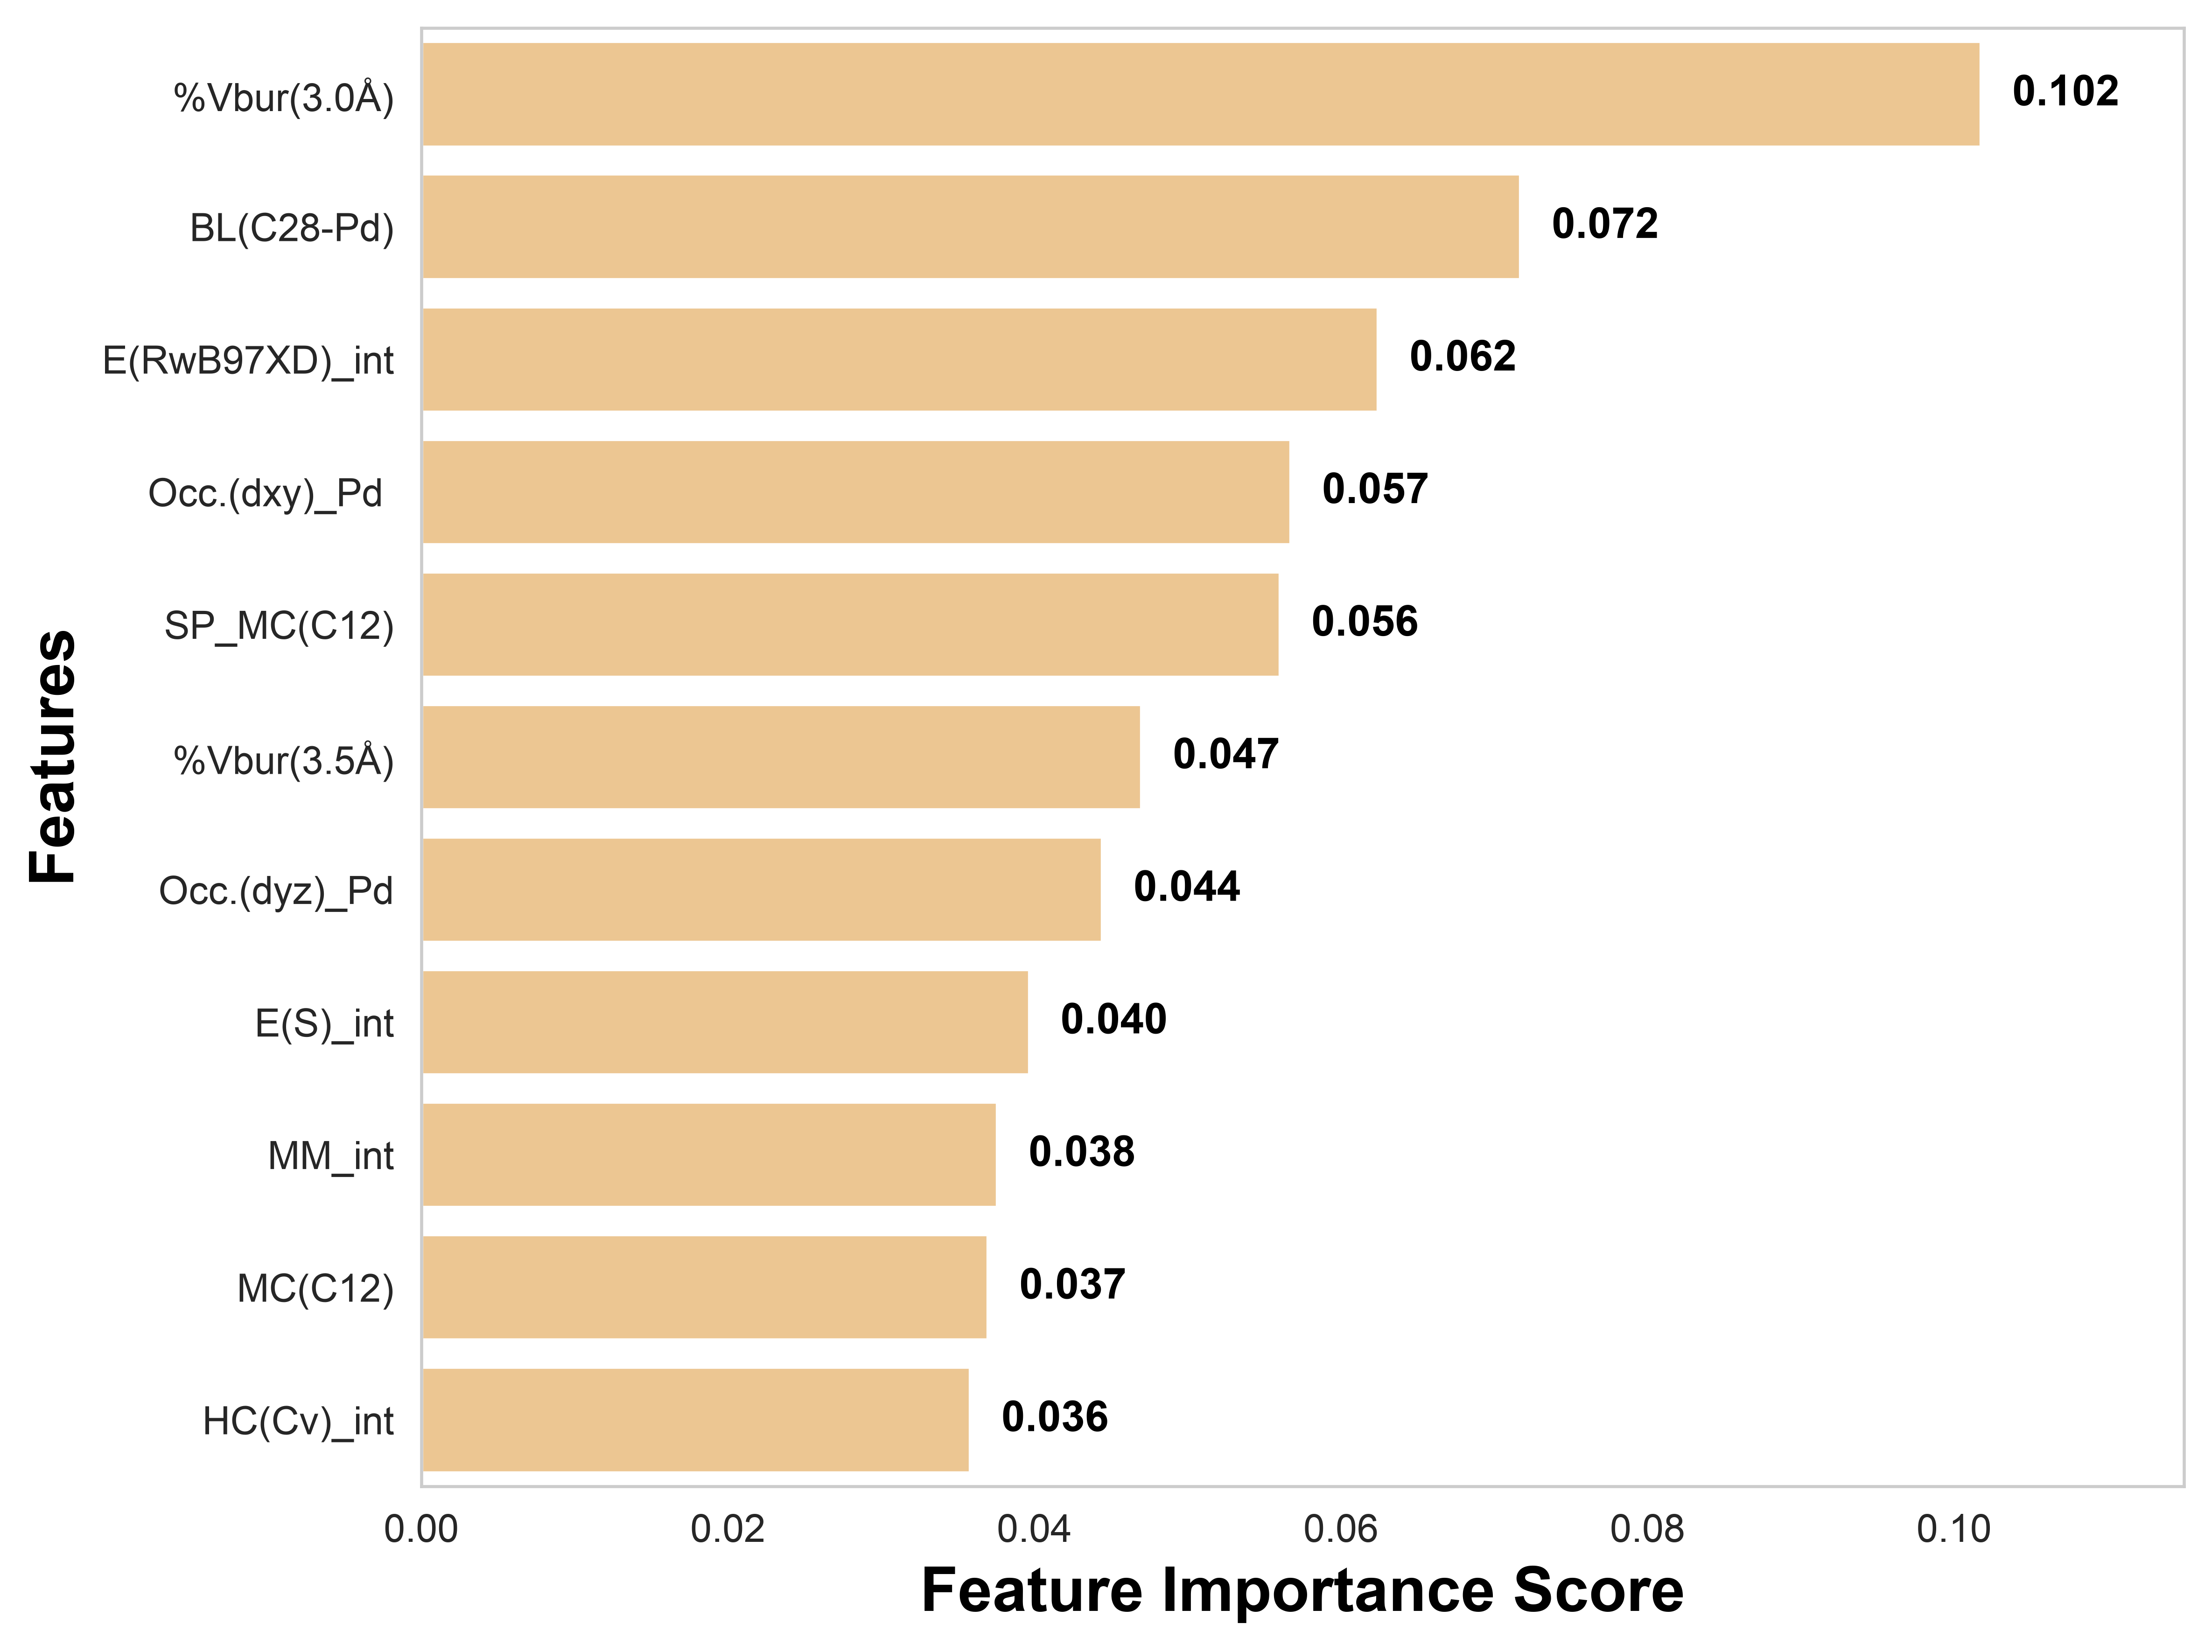

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if filtered_features has data
print(filtered_features)

# Set plot style
sns.set_style("whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=600)

# Light ornage color
bar_color = "#FBC883"

# Plot the bar chart
sns.barplot(
    x=filtered_features.values,
    y=filtered_features.index,
    ax=ax,
    color=bar_color
)

# Remove gridlines
ax.grid(False)

# Add values on bars
for i, value in enumerate(filtered_features.values):
    ax.text(
        value + 0.002,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

# Customize labels
ax.set_xlabel(
    "Feature Importance Score",
    fontsize=16,
    fontweight="bold",
    color="black"
)

ax.set_ylabel(
    "Features",
    fontsize=16,
    fontweight="bold",
    color="black"
)

# Extend x-axis
ax.set_xlim(0, 0.115)

# Improve layout
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Save high-resolution PNG
plt.savefig(
    "Figure 3A.png",
    format="png",
    dpi=600,
    bbox_inches="tight"
)

# Show plot
plt.show()